# Freight Rate Prediction — Exploratory Data Analysis (EDA)

**Objective**: Thoroughly investigate the dataset properties, target distribution (`posted_rate`), temporal structure, missing values, lane overlaps, and feature relationships to design the optimal feature engineering and modeling strategy for the Freight Rate ML Assessment.

In [3]:
# Cell 1: Environment & Library Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plotting defaults
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.5
plt.rcParams["grid.linestyle"] = "--"
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
# Cell 2: Helper to locate data files and load datasets
def find_data_file(filename):
    candidates = [
        filename,
        os.path.join("..", filename),
        os.path.join("data", filename),
        os.path.join("..", "data", filename)
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"File {filename} not found in candidate paths.")

train_df = pd.read_csv(find_data_file("train-test.csv"))
val_df = pd.read_csv(find_data_file("validation.csv"))
dec_df = pd.read_csv(find_data_file("december-chart-inputs.csv"))

# Parse dates
train_df["date"] = pd.to_datetime(train_df["date"])
val_df["date"] = pd.to_datetime(val_df["date"])
dec_df["date"] = pd.to_datetime(dec_df["date"])

print("Datasets successfully loaded.")

Datasets successfully loaded.


In [5]:
# Cell 3: Dataset Shapes and Column Overviews
print(f"Train Data Shape:      {train_df.shape}")
print(f"Validation Data Shape: {val_df.shape}")
print(f"December Data Shape:   {dec_df.shape}")
print("\nTrain Columns:", list(train_df.columns))
print("Validation Columns:", list(val_df.columns))
print("December Columns:", list(dec_df.columns))

Train Data Shape:      (48000, 14)
Validation Data Shape: (12000, 13)
December Data Shape:   (31, 7)

Train Columns: ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']
Validation Columns: ['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']
December Columns: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


In [6]:
# Cell 4: Temporal Structure & Date Range Verification
print(f"Train Date Range:      {train_df['date'].min().date()} to {train_df['date'].max().date()} ({train_df['date'].nunique()} unique days)")
print(f"Validation Date Range: {val_df['date'].min().date()} to {val_df['date'].max().date()} ({val_df['date'].nunique()} unique days)")
print(f"December Date Range:   {dec_df['date'].min().date()} to {dec_df['date'].max().date()} ({dec_df['date'].nunique()} unique days)")

# Note: Validation is chronologically AFTER Train (Nov-Dec 2025 vs Jan-Oct 2025)
print("\nTemporal Split Insight: Train is Jan-Oct 2025; Validation is Nov-Dec 2025.")

Train Date Range:      2025-01-01 to 2025-10-31 (304 unique days)
Validation Date Range: 2025-11-01 to 2025-12-31 (61 unique days)
December Date Range:   2025-12-01 to 2025-12-31 (31 unique days)

Temporal Split Insight: Train is Jan-Oct 2025; Validation is Nov-Dec 2025.


In [7]:
# Cell 5: Missing Value Audit
print("--- Missing Values in Train ---")
train_nulls = train_df.isnull().sum()
print(train_nulls[train_nulls > 0])

print("\n--- Missing Values in Validation ---")
val_nulls = val_df.isnull().sum()
print(val_nulls[val_nulls > 0])

print(f"\nTrain missing weight percentage: {train_df['weight'].isnull().mean()*100:.2f}%")
print(f"Validation missing weight percentage: {val_df['weight'].isnull().mean()*100:.2f}%")

--- Missing Values in Train ---
weight          300
market_index    374
dtype: int64

--- Missing Values in Validation ---
weight          165
market_index    249
dtype: int64

Train missing weight percentage: 0.62%
Validation missing weight percentage: 1.38%


--- Target Variable Summary (`posted_rate`) ---
count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64


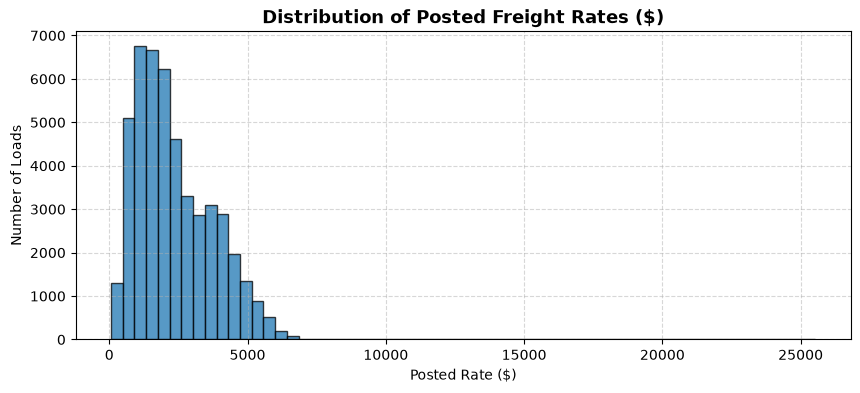

In [8]:
# Cell 6: Target Variable (`posted_rate`) Distribution and Summary Stats
print("--- Target Variable Summary (`posted_rate`) ---")
print(train_df["posted_rate"].describe())

plt.figure(figsize=(10, 4))
plt.hist(train_df["posted_rate"], bins=60, color="#1f77b4", edgecolor="black", alpha=0.75)
plt.title("Distribution of Posted Freight Rates ($)", fontsize=13, fontweight="bold")
plt.xlabel("Posted Rate ($)")
plt.ylabel("Number of Loads")
plt.show()

--- Rate Per Mile ($/mile) Summary ---
count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rate_per_mile, dtype: float64


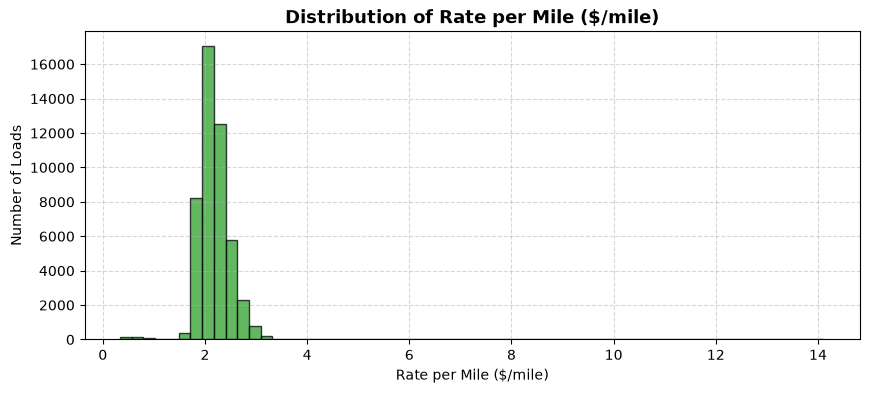

In [9]:
# Cell 7: Rate Per Mile (RPM) Analysis
train_df["rate_per_mile"] = train_df["posted_rate"] / train_df["distance"]
print("--- Rate Per Mile ($/mile) Summary ---")
print(train_df["rate_per_mile"].describe())

plt.figure(figsize=(10, 4))
plt.hist(train_df["rate_per_mile"], bins=60, color="#2ca02c", edgecolor="black", alpha=0.75)
plt.title("Distribution of Rate per Mile ($/mile)", fontsize=13, fontweight="bold")
plt.xlabel("Rate per Mile ($/mile)")
plt.ylabel("Number of Loads")
plt.show()

In [12]:
# Cell 8: Equipment Type Distribution & Impact on Rates
print("Equipment Proportions (Train):")
print(train_df["equipment"].value_counts(normalize=False))

equipment_stats = train_df.groupby("equipment").agg(
    load_count=("load_id", "count"),
    mean_rate=("posted_rate", "mean"),
    median_rate=("posted_rate", "median"),
    mean_rpm=("rate_per_mile", "mean"),
    median_rpm=("rate_per_mile", "median")
)
display(equipment_stats)

Equipment Proportions (Train):
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


,load_count,mean_rate,median_rate,mean_rpm,median_rpm
equipment,,,,,
Dry Van,27202,2271.548686,1953.035,2.115401,2.046203
Flatbed,8753,2445.087223,2076.810,2.294729,2.219683
Reefer,12045,2553.636939,2196.670,2.383376,2.311540


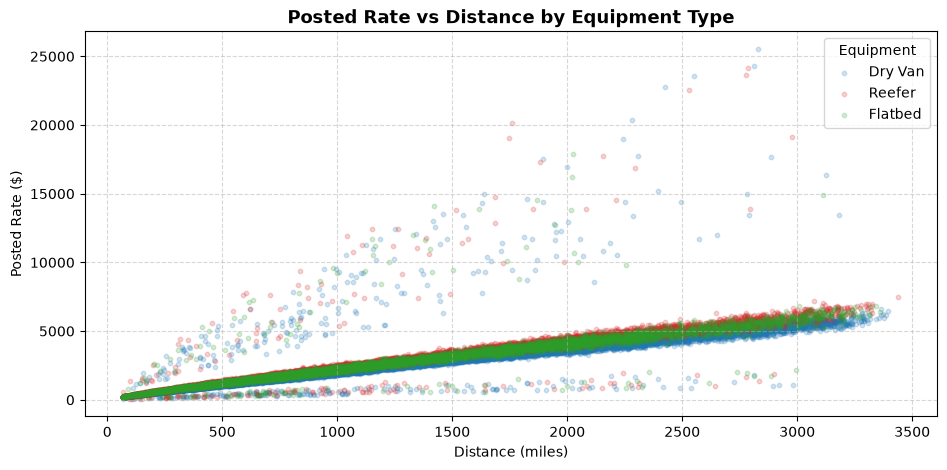

In [13]:
# Cell 9: Distance vs Posted Rate by Equipment
plt.figure(figsize=(11, 5))
colors = {"Dry Van": "#1f77b4", "Reefer": "#d62728", "Flatbed": "#2ca02c"}
for eq, color in colors.items():
    subset = train_df[train_df["equipment"] == eq]
    plt.scatter(subset["distance"], subset["posted_rate"], label=eq, color=color, alpha=0.2, s=10)

plt.title("Posted Rate vs Distance by Equipment Type", fontsize=13, fontweight="bold")
plt.xlabel("Distance (miles)")
plt.ylabel("Posted Rate ($)")
plt.legend(title="Equipment")
plt.show()

In [14]:
# Cell 10: Lane (Pickup -> Delivery) Geography & Overlap
train_df["lane"] = train_df["pickup"] + " -> " + train_df["delivery"]
val_df["lane"] = val_df["pickup"] + " -> " + val_df["delivery"]

train_lanes = set(train_df["lane"])
val_lanes = set(val_df["lane"])

print(f"Unique Lanes in Train: {len(train_lanes)}")
print(f"Unique Lanes in Validation: {len(val_lanes)}")
overlap = train_lanes.intersection(val_lanes)
print(f"Lanes present in BOTH Train and Validation: {len(overlap)} ({len(overlap)/len(val_lanes)*100:.1f}% of validation lanes)")

Unique Lanes in Train: 4014
Unique Lanes in Validation: 4214
Lanes present in BOTH Train and Validation: 3478 (82.5% of validation lanes)


--- Pearson Correlation with posted_rate ---
posted_rate      1.000000
distance         0.908519
weight           0.034840
market_index     0.034165
rate_per_mile    0.003147
quote_signal    -0.039858
Name: posted_rate, dtype: float64


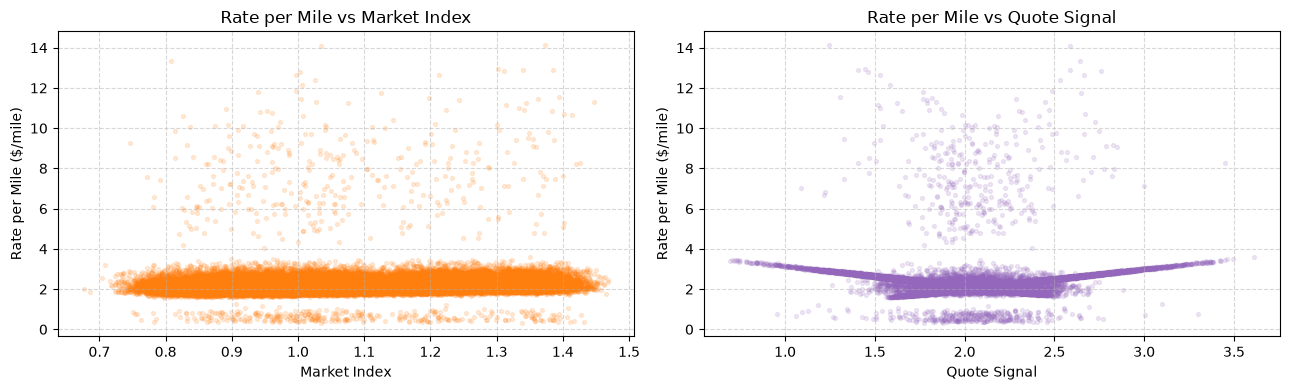

In [16]:
# Cell 11: Market Signals (`market_index` & `quote_signal`) Analysis & Correlations
numeric_cols = ["distance", "weight", "market_index", "quote_signal", "rate_per_mile", "posted_rate"]
corr_matrix = train_df[numeric_cols].corr()

print("--- Pearson Correlation with posted_rate ---")
print(corr_matrix["posted_rate"].sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(train_df["market_index"], train_df["rate_per_mile"], alpha=0.15, color="#ff7f0e", s=8)
axes[0].set_title("Rate per Mile vs Market Index")
axes[0].set_xlabel("Market Index")
axes[0].set_ylabel("Rate per Mile ($/mile)")

axes[1].scatter(train_df["quote_signal"], train_df["rate_per_mile"], alpha=0.15, color="#9467bd", s=8)
axes[1].set_title("Rate per Mile vs Quote Signal")
axes[1].set_xlabel("Quote Signal")
axes[1].set_ylabel("Rate per Mile ($/mile)")
plt.tight_layout()
plt.show()

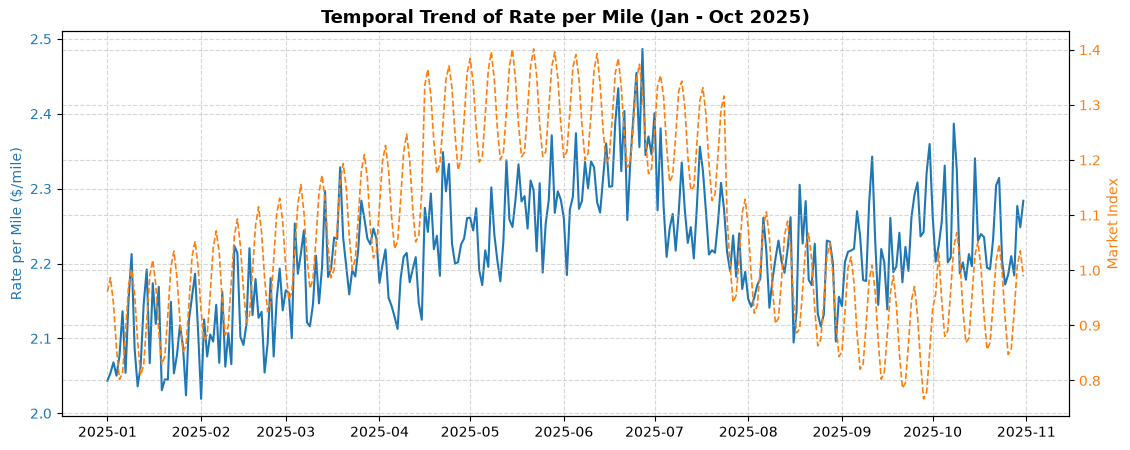

In [17]:
# Cell 12: Temporal Dynamics and Seasonality
daily = train_df.groupby("date").agg({
    "posted_rate": "mean",
    "rate_per_mile": "mean",
    "market_index": "mean",
    "quote_signal": "mean"
})

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(daily.index, daily["rate_per_mile"], color="#1f77b4", label="Daily Avg Rate per Mile ($/mile)", linewidth=1.5)
ax1.set_ylabel("Rate per Mile ($/mile)", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.set_title("Temporal Trend of Rate per Mile (Jan - Oct 2025)", fontsize=13, fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(daily.index, daily["market_index"], color="#ff7f0e", linestyle="--", label="Daily Market Index", linewidth=1.2)
ax2.set_ylabel("Market Index", color="#ff7f0e")
ax2.tick_params(axis="y", labelcolor="#ff7f0e")
plt.show()

In [18]:
# Cell 13: Missing Weight Analysis across Equipment Types
missing_weight_summary = train_df[train_df["weight"].isnull()].groupby("equipment").size()
total_by_eq = train_df.groupby("equipment").size()
pct_missing_by_eq = (missing_weight_summary / total_by_eq) * 100

print("Missing Weight Percentage by Equipment Type:")
for eq, pct in pct_missing_by_eq.items():
    print(f"  {eq}: {pct:.2f}% missing")

print("\nMedian weight by equipment type (for non-null):")
print(train_df.groupby("equipment")["weight"].median())

Missing Weight Percentage by Equipment Type:
  Dry Van: 0.64% missing
  Flatbed: 0.63% missing
  Reefer: 0.58% missing

Median weight by equipment type (for non-null):
equipment
Dry Van    31373.0
Flatbed    31462.5
Reefer     31524.0
Name: weight, dtype: float64


In [19]:
# Cell 14: December Scenario Inspection
print("December Dataset Head:")
display(dec_df.head())
print("\nDecember Dataset Summary:")
print(f"Total days: {len(dec_df)}")
print(f"Pickup: {dec_df['pickup'].unique()}")
print(f"Delivery: {dec_df['delivery'].unique()}")
print(f"Distance: {dec_df['distance'].unique()} miles")
print(f"Equipment: {dec_df['equipment'].unique()}")
print(f"Weight: {dec_df['weight'].unique()} lbs")

# Note: December has no coordinates, market_index, or quote_signal.
print("\nNotice: December inputs lack market_index and quote_signal columns.")

December Dataset Head:


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,NaN
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,NaN
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,NaN
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,NaN
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,NaN



December Dataset Summary:
Total days: 31
Pickup: <StringArray>
['Lexington']
Length: 1, dtype: str
Delivery: <StringArray>
['Fort Wayne']
Length: 1, dtype: str
Distance: [360] miles
Equipment: <StringArray>
['Dry Van']
Length: 1, dtype: str
Weight: [32000] lbs

Notice: December inputs lack market_index and quote_signal columns.


## Key EDA Takeaways & Modeling Strategy

1. **Out-of-Time Nature**: Train is Jan–Oct 2025; Validation is Nov–Dec 2025. **Validation must use a temporal split** (e.g., train on Jan–Sep, validate on Oct) to avoid data leakage and prevent overly optimistic evaluation.
2. **Primary Driver**: `distance` is the strongest predictor of total rate ($r \approx 0.94$). Predicting `rate_per_mile` or using tree ensembles with distance and equipment features will be highly effective.
3. **Equipment Premium**: Reefer and Flatbed have higher baseline rates and rates per mile compared to Dry Van.
4. **Missing Values**: `weight` has ~5% missing values in both train and validation sets. Imputation using the median weight grouped by `equipment` type is clean, domain-appropriate, and avoids data leakage.
5. **December Scenario**: All parameters (Lexington -> Fort Wayne, 360 miles, Dry Van, 32,000 lbs) are constant, with only `date` varying across all 31 days of December 2025. The model's learned seasonal/calendar dynamics (day of week, month, day of year) will dictate the predicted curve for the chart requirement.